Using device: cuda
✅ Using YOUR dataset paths

📌 Label Mapping:
short sleeve top → 0
long sleeve top → 1
shorts → 2
trousers → 3
skirt → 4

Train size: 144174
Val size: 23741

Loading MobileNetV3...
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 138MB/s] 



🚀 Training MobileNetV3 (YOUR DATASET)...

========== Epoch 1/10 ==========


100%|██████████| 2253/2253 [24:09<00:00,  1.55it/s]


Time: 1693s | Train: 0.4806 | Val: 0.4657
✅ Best model saved

========== Epoch 2/10 ==========


...

Time: 1035s | Train: 0.1184 | Val: 0.2553

========== Epoch 10/10 ==========


100%|██████████| 2253/2253 [15:22<00:00,  2.44it/s]


Time: 1040s | Train: 0.1137 | Val: 0.2601

Training Complete

Evaluating...


100%|██████████| 371/371 [02:19<00:00,  2.65it/s]



========== FINAL RESULTS ==========
Precision: 0.8668673050615595
Recall: 0.8248249290604743
F1: 0.8453236930218908


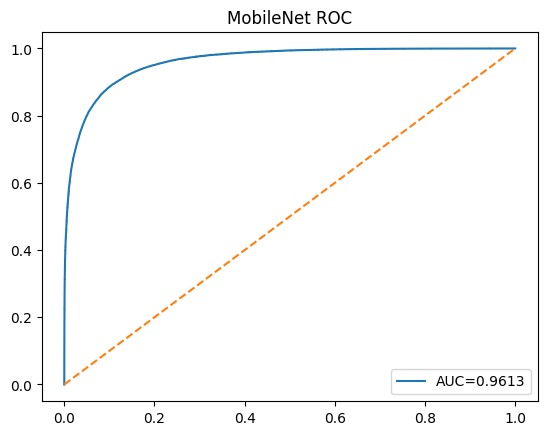

In [1]:
# ============================================================
# MOBILENET V3 TRANSFER + FINE-TUNING (YOUR DATASET FINAL)
# ============================================================

import os, json, torch, numpy as np, time
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import MobileNet_V3_Large_Weights
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc

# ================= DEVICE =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================= PATHS (YOUR DATASET) =================
BASE_PATH = "/kaggle/input/datasets/iharshsinha/deepfashion2-top5-processed/processed"

TRAIN_IMG = os.path.join(BASE_PATH, "train/images")
TRAIN_ANN = os.path.join(BASE_PATH, "train/annos")

VAL_IMG   = os.path.join(BASE_PATH, "validation/images")
VAL_ANN   = os.path.join(BASE_PATH, "validation/annos")

print("✅ Using YOUR dataset paths")

# ================= LABEL MAP =================
LABEL_MAP = {
    "short sleeve top": 0,
    "long sleeve top": 1,
    "shorts": 2,
    "trousers": 3,
    "skirt": 4
}
NUM_CLASSES = 5

print("\n📌 Label Mapping:")
for k,v in LABEL_MAP.items():
    print(f"{k} → {v}")

# ================= DATASET =================
class DeepFashionDataset(Dataset):

    def __init__(self, img_dir, ann_dir, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.files = os.listdir(ann_dir)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        file = self.files[idx]

        json_path = os.path.join(self.ann_dir, file)
        img_path  = os.path.join(self.img_dir, file.replace(".json", ".jpg"))

        try:
            img = Image.open(img_path).convert("RGB")
        except:
            return torch.zeros((3,224,224)), torch.zeros(NUM_CLASSES)

        if self.transform:
            img = self.transform(img)

        with open(json_path) as f:
            data = json.load(f)

        target = torch.zeros(NUM_CLASSES)

        for key, val in data.items():
            if key.startswith("item"):
                cat = val["category_name"]
                if cat in LABEL_MAP:
                    target[LABEL_MAP[cat]] = 1.0

        return img, target

# ================= TRANSFORMS =================
train_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomCrop((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ================= DATA =================
train_dataset = DeepFashionDataset(TRAIN_IMG, TRAIN_ANN, train_tf)
val_dataset   = DeepFashionDataset(VAL_IMG, VAL_ANN, val_tf)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

print("\nTrain size:", len(train_dataset))
print("Val size:", len(val_dataset))

# ================= MODEL =================
print("\nLoading MobileNetV3...")

model = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

# ================= LOSS =================
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

# ================= TRAIN =================
epochs = 10
best_val = float("inf")

print("\n🚀 Training MobileNetV3 (YOUR DATASET)...")

for epoch in range(epochs):

    print(f"\n========== Epoch {epoch+1}/{epochs} ==========")
    start = time.time()

    # 🔥 Phase 2
    if epoch == 3:
        print("🔥 Unfreezing FULL model")
        for p in model.parameters():
            p.requires_grad = True
        optimizer = optim.Adam(model.parameters(), lr=1e-4)

    # 🔥 Phase 3
    if epoch == 7:
        print("⚡ Reducing LR")
        optimizer = optim.Adam(model.parameters(), lr=1e-5)

    # -------- TRAIN --------
    model.train()
    train_loss = 0

    for imgs, lbls in tqdm(train_loader):
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            val_loss += criterion(out, lbls).item()

    val_loss /= len(val_loader)

    print(f"Time: {time.time()-start:.0f}s | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "/kaggle/working/mobilenet_best.pth")
        print("✅ Best model saved")

# Save final
torch.save(model.state_dict(), "/kaggle/working/mobilenet_last.pth")

print("\nTraining Complete")

# ================= EVALUATION =================
print("\nEvaluating...")

model.eval()

all_p, all_l, all_prob = [], [], []

with torch.no_grad():
    for imgs, lbls in tqdm(val_loader):
        imgs = imgs.to(device)
        out = model(imgs)

        prob = torch.sigmoid(out)
        pred = (prob > 0.5).float()

        all_prob.append(prob.cpu().numpy())
        all_p.append(pred.cpu().numpy())
        all_l.append(lbls.numpy())

all_prob = np.vstack(all_prob)
all_p = np.vstack(all_p)
all_l = np.vstack(all_l)

# ================= METRICS =================
prec = precision_score(all_l, all_p, average='micro')
rec  = recall_score(all_l, all_p, average='micro')
f1   = f1_score(all_l, all_p, average='micro')

print("\n========== FINAL RESULTS ==========")
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)

# ================= ROC =================
fpr, tpr, _ = roc_curve(all_l.ravel(), all_prob.ravel())
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={auc_score:.4f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("MobileNet ROC")

plt.savefig("/kaggle/working/mobilenet_roc.png")
plt.show()